In [36]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as f
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import Window

spark = (
    SparkSession.builder
    .appName("preprocess_batch")
    .master("spark://spark-master:7077")
    .enableHiveSupport()
    .config("hive.metastore.uris", "thrift://hive-metastore:9083")
    # metastore.uris może być w hive-site.xml (i w sumie powinno być, ale nie chce mi się ruszać docker-compose już xd),
    # ale nadpisanie tutaj jest ok
    .config("spark.cores.max", "1")
    .config("spark.executor.cores", "1")
    .getOrCreate()
)

spark.sql("USE CryptoPredictions")

DataFrame[]

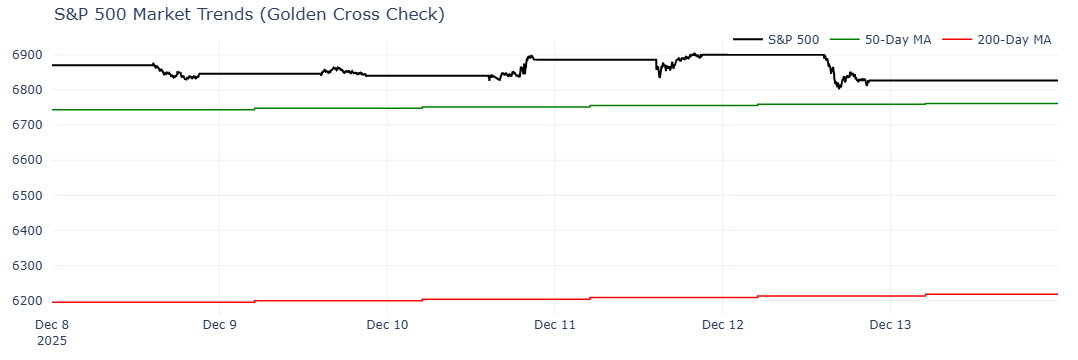

In [13]:
# Stock Prices S&P
query = f"""SELECT cast(Datetime as string) as Datetime_Str, CurrentPrice, FiftyDayAveragePrice, TwoHundredDaysAveragePrice
FROM IndexSnapshot WHERE IndexName = 'SNP' AND Datetime BETWEEN "2025-12-08" AND "2025-12-14" ORDER BY Datetime DESC"""
df = spark.sql(query).toPandas()

df['Datetime'] = pd.to_datetime(df['Datetime_Str'])
for c in ['CurrentPrice', 'FiftyDayAveragePrice', 'TwoHundredDaysAveragePrice']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df_stock = df.sort_values("Datetime")

fig = go.Figure()
# Price Line
fig.add_trace(go.Scatter(x=df_stock['Datetime'], y=df_stock['CurrentPrice'], mode='lines', name='S&P 500',
                         line=dict(color='black', width=2)))
# Moving Averages
fig.add_trace(go.Scatter(x=df_stock['Datetime'], y=df_stock['FiftyDayAveragePrice'], mode='lines', name='50-Day MA',
                         line=dict(color='green', width=1.5)))
fig.add_trace(
    go.Scatter(x=df_stock['Datetime'], y=df_stock['TwoHundredDaysAveragePrice'], mode='lines', name='200-Day MA',
               line=dict(color='red', width=1.5)))

fig.update_layout(
    title="S&P 500 Market Trends (Golden Cross Check)",
    template="plotly_white",
    hovermode="x unified",
    margin=dict(l=20, r=20, t=40, b=20),
    legend=dict(orientation="h", yanchor="bottom", y=0.95, xanchor="right", x=1)
)

fig.update_yaxes(ticksuffix="  ")

In [19]:
# Is there any missing data?

df = spark.table("CryptocurrencySnapshot")
nulls_df = df.select([
    f.count(f.when(f.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

nulls_df.show(truncate=False)

df = spark.table("IndexSnapshot")
nulls_df = df.select([
    f.count(f.when(f.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

nulls_df.show(truncate=False)

df = spark.table("USDExchangeRates")
nulls_df = df.select([
    f.count(f.when(f.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

nulls_df.show(truncate=False)

+------+--------+------------+------------+--------------+---------------+--------------------+-------------+
|Symbol|Datetime|CurrentPrice|OpeningPrice|LowestDayPrice|HighestDayPrice|PreviousClosingPrice|PartitionDate|
+------+--------+------------+------------+--------------+---------------+--------------------+-------------+
|0     |0       |0           |0           |0             |0              |0                   |0            |
+------+--------+------------+------------+--------------+---------------+--------------------+-------------+



+---------+--------+------------+-------------+------------+--------------+---------------+-----------------+------------------+--------------------+--------------------------+-------------------+-----------------------+-----------------------+-------------+
|IndexName|Datetime|CurrentPrice|CurrentVolume|OpeningPrice|LowestDayPrice|HighestDayPrice|LowestYearlyPrice|HighestYearlyPrice|FiftyDayAveragePrice|TwoHundredDaysAveragePrice|TenDayAverageVolume|ThreeMonthAverageVolume|YearOverYearPriceChange|PartitionDate|
+---------+--------+------------+-------------+------------+--------------+---------------+-----------------+------------------+--------------------+--------------------------+-------------------+-----------------------+-----------------------+-------------+
|339      |0       |339         |339          |339         |339           |339            |339              |339               |339                 |339                       |339                |339                    |339

In [46]:
df = spark.table("IndexSnapshot")

exclude_cols = ["Datetime", "PartitionDate"]

check_cols = [c for c in df.columns if c not in exclude_cols]

condition = " OR ".join([f"{c} IS NULL" for c in check_cols])

null_rows = df.filter(condition)

nulls_per_hour = (
    null_rows
    .withColumn(
        "hour",
        f.date_format(f.col("Datetime"), "yyyy-MM-dd HH:00:00")
    )
    .select("hour")
    .groupBy("hour")
    .count()
    .orderBy("hour")
)

pdf = nulls_per_hour.toPandas()
pdf["hour"] = pd.to_datetime(pdf["hour"])

All rows:  115482
         date  count
0  2025-11-18  173.0
1  2025-11-19    3.0
2  2025-11-20    1.0
3  2025-11-21   12.0
4  2025-11-22    0.0
5  2025-11-23    2.0
6  2025-11-24    0.0
7  2025-11-25    0.0
8  2025-11-26    0.0
9  2025-11-27    3.0
10 2025-11-28    0.0
11 2025-11-29    3.0
12 2025-11-30  115.0
13 2025-12-01    1.0
14 2025-12-02    0.0
15 2025-12-03    2.0
16 2025-12-04    1.0
17 2025-12-05    2.0
18 2025-12-06    0.0
19 2025-12-07    0.0
20 2025-12-08    0.0
21 2025-12-09   12.0
22 2025-12-10    0.0
23 2025-12-11    0.0
24 2025-12-12    0.0
25 2025-12-13    6.0
26 2025-12-14    3.0


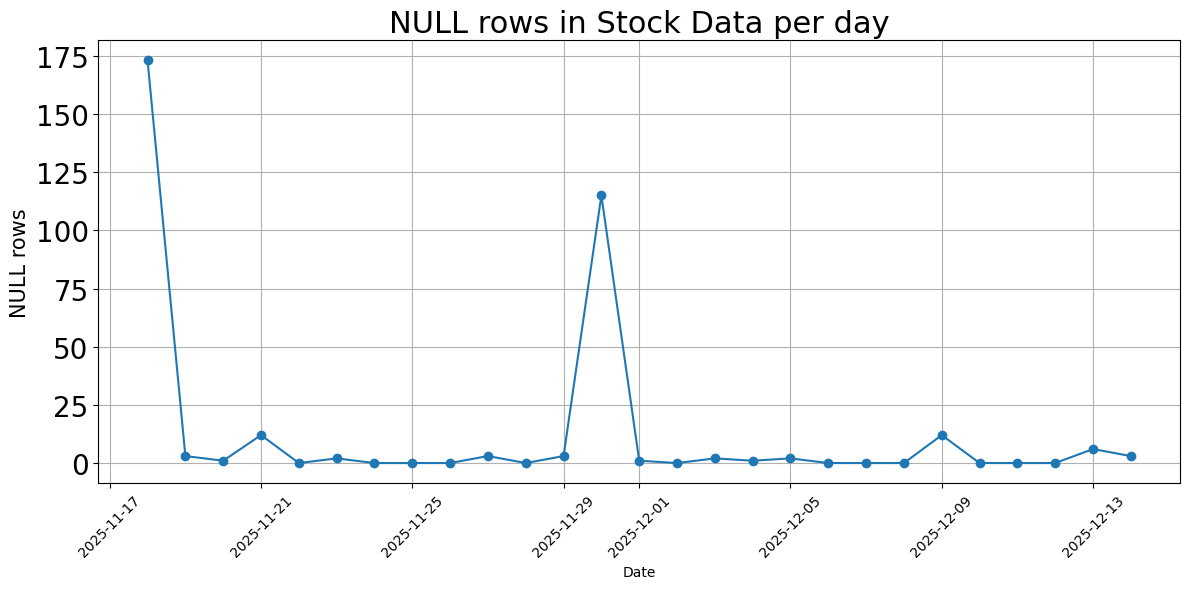

In [68]:
pdf['date'] = pd.to_datetime(pdf['hour'].dt.date)
daily_nulls = pdf.groupby('date')['count'].sum().reset_index()

full_dates = pd.DataFrame({'date': pd.date_range(daily_nulls['date'].min(),
                                                 daily_nulls['date'].max())})

# Scalanie i wypełnianie brakujących dni zerami
daily_nulls_full = full_dates.merge(daily_nulls, how='left', left_on='date', right_on='date')
daily_nulls_full['count'] = daily_nulls_full['count'].fillna(0)

# Wyświetlamy wynik
print(f"All rows: ", df.count())
print(daily_nulls_full)


plt.figure(figsize=(12, 6))
plt.plot(daily_nulls_full['date'], daily_nulls_full['count'], marker='o', linestyle='-')
plt.xlabel('Date', fontsize = 10)
plt.xticks(fontsize = 10)
plt.ylabel('NULL rows', fontsize = 15)
plt.yticks(fontsize = 20)
plt.title('NULL rows in Stock Data per day', fontsize = 22)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
